## Introducere

Acest notebook demonstrează aplicarea unui algoritm genetic pentru a găsi parametrii unei funcții pătratice ($f(x) = ax^2 + bx + c$) care să aibă o formă de "U" cât mai plată. Algoritmul genetic este o tehnică de optimizare euristică, inspirată din teoria evoluției prin selecție naturală.

Principiul de bază constă în evoluția unei populații de soluții posibile (numite indivizi), fiecare fiind evaluată printr-o funcție de "fitness" (grad de adaptare). Indivizii cu un fitness superior sunt selectați pentru a se reproduce, generând noi soluții (copii) care moștenesc trăsături de la părinți. Acest proces iterativ de selecție, recombinare și mutație conduce la convergența către soluții din ce în ce mai bune.

În acest caz, fiecare "individ" este un set de parametri (a, b, c) ce definesc o funcție pătratică. Obiectivul este minimizarea "curburii" funcției, pentru a obține un grafic cât mai plat, păstrând forma de "U" (cu ramurile orientate în sus).

Spre deosebire de metodele analitice, cum ar fi cele bazate pe gradient, algoritmii genetici nu necesită ca funcția obiectiv să fie derivabilă sau convexă. Această flexibilitate îi face potriviți pentru spații de căutare complexe sau probleme în care funcția de fitness este euristică, așa cum este cazul de față.


## Importarea bibliotecilor

Pentru implementarea algoritmului și vizualizarea rezultatelor, sunt necesare următoarele biblioteci Python:

- **random**: pentru operațiile stocastice: generarea populației inițiale, selecția și mutația.
- **matplotlib.pyplot**: pentru crearea de grafice și vizualizări ale evoluției și rezultatelor.
- **numpy**: pentru operații numerice eficiente, utilizat aici la generarea de date pentru grafice.
- **prettytable**: pentru afișarea datelor într-un format tabelar lizibil.


In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np
from prettytable import PrettyTable


## Definirea funcției de fitness

Funcția de fitness este componenta centrală a algoritmului, deoarece cuantifică performanța fiecărei soluții. Aceasta atribuie o valoare numerică fiecărui individ, permițând algoritmului să compare soluțiile și să le prioritizeze pe cele mai performante.

Pentru problema de față, funcția de fitness trebuie să evalueze cât de "plată" este o parabolă, respectând constrângerea formei de "U". Pașii sunt următorii:

1.  **Penalizarea soluțiilor invalide**: O formă de "U" presupune o parabolă cu ramurile în sus, deci parametrul `a` trebuie să fie pozitiv. Soluțiile cu `a` negativ sau zero sunt puternic penalizate, fiind efectiv eliminate din procesul de selecție.
2.  **Identificarea punctului de minim**: Se calculează coordonatele vârfului parabolei ($V_x = -b / (2a)$, $V_y = f(V_x)$), care este punctul de minim al funcției.
3.  **Măsurarea curburii**: Se definește o **metrică euristică** pentru curbură. Aceasta este aproximată prin suma diferențelor absolute dintre valoarea funcției la capetele intervalului de interes [-1, 1] și valoarea în punctul de vârf. O valoare mică a acestei sume indică o curbură redusă, deci o funcție mai plată.
4.  **Calculul valorii de fitness**: Deoarece convenția în algoritmii genetici este de a maximiza funcția de fitness, iar obiectivul nostru este de a minimiza curbura, funcția de fitness va returna valoarea negativă a curburii calculate.


In [2]:
# Define the fitness function (objective is to create the flattest U-shape)
def fitness_function(params):
    a, b, c = params
    if a <= 0:
        return -float('inf')  # Penalize downward facing u-shapes heavily
    vertex_x = -b / (2 * a) #x value at vertex
    vertex_y = a * (vertex_x ** 2) + b * vertex_x + c #y value at vertex
    y_left = a * (-1) ** 2 + b * (-1) + c #y-coordinate at x = -1
    y_right = a * (1) ** 2 + b * (1) + c #y-coordinate at x = 1
    curviness = abs(y_left - vertex_y) + abs(y_right - vertex_y)
    return -curviness  # Negate to minimize curviness


## Crearea populației inițiale

Procesul evolutiv pornește de la o populație de soluții generate aleatoriu. Fiecare soluție (individ) este un tuplu de parametri (a, b, c).

Funcția `create_initial_population` generează o listă de astfel de indivizi, în număr definit de parametrul `size`. Fiecare parametru (genă) este un număr real, generat aleatoriu în intervalul specificat de `gene_lower_bound` și `gene_upper_bound`. Folosirea unui generator de numere aleatoare (`rng`) cu o sămânță (seed) predefinită asigură reproductibilitatea rezultatelor.


In [3]:
# Create the initial population
def create_initial_population(size, gene_lower_bound, gene_upper_bound, rng):
    population = []
    for _ in range(size):
        individual = (rng.uniform(gene_lower_bound, gene_upper_bound),
                      rng.uniform(gene_lower_bound, gene_upper_bound),
                      rng.uniform(gene_lower_bound, gene_upper_bound))
        population.append(individual)
    # print(population)
    return population


## Selecția indivizilor

Selecția este mecanismul prin care indivizii sunt aleși pentru a contribui la generația următoare. Indivizii cu un scor de fitness mai bun au o probabilitate mai mare de a fi selectați.

În acest caz, se utilizează **selecția prin turneu (tournament selection)**. Mecanismul este următorul:
1.  Un subgrup de indivizi (`tournament_size`) este ales aleatoriu din populația curentă.
2.  Individul cu cel mai mare scor de fitness din acest subgrup este selectat.
3.  Procesul se repetă până se formează o nouă populație de părinți, de aceeași dimensiune cu cea inițială.

Această metodă de selecție este robustă, echilibrând eficient explorarea de noi soluții cu exploatarea celor mai bune rezultate deja obținute.


In [4]:
# Selection function using tournament selection
def selection(population, fitnesses, rng, tournament_size=3):
    selected = []
    for _ in range(len(population)):
        tournament = rng.sample(list(zip(population, fitnesses)), tournament_size)
        winner = max(tournament, key=lambda x: x[1])[0]
        selected.append(winner)
    return selected


## Recombinarea părinților

Recombinarea (crossover) combină materialul genetic a doi părinți pentru a crea noi indivizi (copii), permițând astfel propagarea trăsăturilor valoroase.

Aici se folosește **recombinarea aritmetică**, potrivită pentru reprezentări cu numere reale. Pentru doi părinți, $P_1$ și $P_2$, și un factor aleatoriu $\alpha \in [0, 1]$, copiii $C_1$ și $C_2$ sunt generați ca o combinație liniară:

$C_1 = \alpha \cdot P_1 + (1 - \alpha) \cdot P_2$
$C_2 = \alpha \cdot P_2 + (1 - \alpha) \cdot P_1$

Astfel, copiii moștenesc caracteristici de la ambii părinți, fiind plasați în spațiul de căutare între aceștia.


In [5]:
# Crossover function
def crossover(parent1, parent2, rng):
    alpha = rng.random()
    child1 = tuple(alpha * p1 + (1 - alpha) * p2 for p1, p2 in zip(parent1, parent2))
    child2 = tuple(alpha * p2 + (1 - alpha) * p1 for p1, p2 in zip(parent1, parent2))
    return child1, child2


## Mutația parametrilor

Mutația introduce modificări aleatorii în genele indivizilor, aducând astfel diversitate în populație. Mutația este esențială pentru menținerea diversității genetice, prevenind blocarea algoritmului într-un optim local și facilitând explorarea unor noi zone din spațiul de soluții.

Funcția `mutation` parcurge genele fiecărui individ și, cu o probabilitate `mutation_rate`, le modifică adăugând o valoare aleatorie mică. Valorile genelor sunt menținute în intervalul valid (`gene_lower_bound`, `gene_upper_bound`).


In [6]:
# Mutation function
def mutation(individual, mutation_rate, gene_lower_bound, gene_upper_bound, rng):
    individual = list(individual)
    for i in range(len(individual)):
        if rng.random() < mutation_rate:
            mutation_amount = rng.uniform(-1, 1)
            individual[i] += mutation_amount
            # Ensure the individual stays within bounds
            individual[i] = max(min(individual[i], gene_upper_bound), gene_lower_bound)
    return tuple(individual)


## Rularea algoritmului genetic

Funcția `genetic_algorithm` integrează toate componentele definite anterior pentru a desfășura procesul evolutiv de-a lungul mai multor generații.

Ciclul de viață al algoritmului este:

1.  **Inițializare**: Se creează populația inițială și se pregătesc structurile de date pentru colectarea statisticilor.
2.  **Bucla evolutivă**: Pentru fiecare generație:
    a. **Evaluare**: Se calculează fitness-ul pentru fiecare individ.

    b. **Stocare date**: Se salvează cel mai bun individ și starea populației pentru analiză ulterioară.

    c. **Elitism**: Un număr mic de indivizi de top (`elitism_count`) sunt transferați direct în generația următoare, asigurând păstrarea celor mai bune soluții.

    d. **Selecție**: Se aleg părinții pentru noua generație prin metoda turneului.

    e. **Crearea noii generații**: Părinții selectați sunt recombinați și copiii rezultați suferă mutații. Noua populație este formată din elitiști și din copiii nou-creați

    f. **Înlocuire**: Populația veche este înlocuită cu cea nouă.

3.  **Finalizare**: La atingerea numărului de generații specificat, algoritmul se oprește. La final, funcția returnează cea mai bună soluție identificată, alături de un set de date statistice colectate pe parcursul generațiilor.


In [7]:
# Main genetic algorithm function
def genetic_algorithm(population_size, gene_lower_bound, gene_upper_bound, x_plot_min, x_plot_max, generations, mutation_rate, random_seed, tournament_size, elitism_count):
    rng = random.Random() if random_seed is None else random.Random(random_seed)
    if not 0.0 <= mutation_rate <= 1.0:
        raise ValueError("mutation_rate trebuie sa fie intre 0.0 si 1.0")
    population = create_initial_population(population_size, gene_lower_bound, gene_upper_bound, rng)

    best_performers = []
    all_populations = []

    table = PrettyTable()
    table.field_names = ["Generatie", "a", "b", "c", "Scor fitness"]

    for generation in range(generations):
        fitnesses = [fitness_function(ind) for ind in population]

        best_individual = max(population, key=fitness_function)
        best_fitness = fitness_function(best_individual)
        best_performers.append((best_individual, best_fitness))
        all_populations.append(population[:])
        table.add_row([generation + 1, best_individual[0], best_individual[1], best_individual[2], best_fitness])

        elite_count = max(0, min(elitism_count, population_size))
        elites = sorted(population, key=fitness_function, reverse=True)[:elite_count]
        selected_population = selection(population, fitnesses, rng, tournament_size)

        next_population = elites[:]
        parent_index = 0
        while len(next_population) < population_size:
            parent1 = selected_population[parent_index % len(selected_population)]
            parent2 = selected_population[(parent_index + 1) % len(selected_population)]
            parent_index += 2

            child1, child2 = crossover(parent1, parent2, rng)

            next_population.append(mutation(child1, mutation_rate, gene_lower_bound, gene_upper_bound, rng))
            if len(next_population) < population_size:
                next_population.append(mutation(child2, mutation_rate, gene_lower_bound, gene_upper_bound, rng))

        population = next_population

    best_solution = max(population, key=fitness_function)
    return {
        "best_solution": best_solution,
        "best_performers": best_performers,
        "all_populations": all_populations,
        "summary_table": table,
        "x_plot_min": x_plot_min,
        "x_plot_max": x_plot_max,
        "generations": generations,
    }


## Funcții pentru vizualizare

Vizualizarea datelor este crucială pentru a înțelege dinamica procesului evolutiv și pentru a interpreta rezultatele.

-   **`plot_final_population`**: Afișează distribuția valorilor parametrilor (a, b, c) pentru toți indivizii din ultima generație, indicând gradul de convergență al populației.
-   **`plot_parameter_evolution`**: Ilustrează evoluția parametrilor celui mai bun individ de-a lungul generațiilor, arătând traiectoria de optimizare în spațiul parametrilor.
-   **`plot_fitness_evolution`**: Prezintă evoluția scorului de fitness. Graficul include scorul celui mai bun individ și intervalul (minim, maxim) al fitness-ului din întreaga populație, fiind un indicator cheie al progresului.
-   **`plot_quadratic_functions`**: Desenează funcțiile pătratice corespunzătoare celor mai buni indivizi din fiecare generație. Acest grafic ilustrează vizual cum algoritmul "învață" să optimizeze funcțiile, generând parabole progresiv mai plate.


In [8]:
# Plotting functions
def plot_final_population(all_populations, best_performers):
    final_population = all_populations[-1]
    best_individual = best_performers[-1][0]

    fig, axs = plt.subplots(3, 1, figsize=(12, 18))
    axs[0].scatter(range(len(final_population)), [ind[0] for ind in final_population], color="blue", label="a")
    axs[0].scatter([final_population.index(best_individual)], [best_individual[0]], color="cyan", s=100, label="Cel mai bun individ a")
    axs[0].set_ylabel("a", color="blue")
    axs[0].legend(loc="upper left")

    axs[1].scatter(range(len(final_population)), [ind[1] for ind in final_population], color="green", label="b")
    axs[1].scatter([final_population.index(best_individual)], [best_individual[1]], color="magenta", s=100, label="Cel mai bun individ b")
    axs[1].set_ylabel("b", color="green")
    axs[1].legend(loc="upper left")

    axs[2].scatter(range(len(final_population)), [ind[2] for ind in final_population], color="red", label="c")
    axs[2].scatter([final_population.index(best_individual)], [best_individual[2]], color="yellow", s=100, label="Cel mai bun individ c")
    axs[2].set_ylabel("c", color="red")
    axs[2].set_xlabel("Indexul individului")
    axs[2].legend(loc="upper left")
    axs[0].set_title(f"Solutii din populatia generatiei finale ({len(best_performers)})")

def plot_parameter_evolution(best_performers):
    generations_list = range(1, len(best_performers) + 1)
    a_values = [ind[0][0] for ind in best_performers]
    b_values = [ind[0][1] for ind in best_performers]
    c_values = [ind[0][2] for ind in best_performers]

    fig, ax = plt.subplots()
    ax.plot(generations_list, a_values, label="a", color="blue")
    ax.plot(generations_list, b_values, label="b", color="green")
    ax.plot(generations_list, c_values, label="c", color="red")
    ax.set_xlabel("Generatie")
    ax.set_ylabel("Valorile parametrilor")
    ax.set_title("Evolutia valorilor parametrilor")
    ax.legend()

def plot_fitness_evolution(best_performers, all_populations):
    generations_list = range(1, len(best_performers) + 1)
    best_fitness_values = [fit[1] for fit in best_performers]
    min_fitness_values = [min([fitness_function(ind) for ind in population]) for population in all_populations]
    max_fitness_values = [max([fitness_function(ind) for ind in population]) for population in all_populations]

    fig, ax = plt.subplots()
    ax.plot(generations_list, best_fitness_values, label="Cel mai bun scor fitness", color="black")
    ax.fill_between(generations_list, min_fitness_values, max_fitness_values, color="gray", alpha=0.5, label="Intervalul scorului fitness")
    ax.set_xlabel("Generatie")
    ax.set_ylabel("Scor fitness")
    ax.set_title("Evolutia scorului fitness")
    ax.legend()

def plot_quadratic_functions(best_performers, x_plot_min, x_plot_max, generations):
    fig, ax = plt.subplots()
    colors = plt.cm.viridis(np.linspace(0, 1, generations))
    for i, (best_ind, _) in enumerate(best_performers):
        color = colors[i]
        a, b, c = best_ind
        x_range = np.linspace(x_plot_min, x_plot_max, 400)
        y_values = a * (x_range ** 2) + b * x_range + c
        ax.plot(x_range, y_values, color=color)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Funcția pătratică")

    cax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
    norm = plt.cm.colors.Normalize(vmin=0, vmax=generations)
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, cax=cax, orientation="vertical", label="Generatie")


## Setarea parametrilor algoritmului

Calibrarea corectă a parametrilor (hiperparametri) este un pas critic, având un impact semnificativ asupra performanței și eficienței algoritmului genetic.

-   **`generations`**: Numărul total de iterații (generații). O valoare mai mare permite o explorare mai amănunțită, dar crește timpul de execuție.
-   **`population_size`**: Numărul de indivizi dintr-o generație. O populație mai mare crește diversitatea, dar și necesarul de resurse computaționale.
-   **`mutation_rate`**: Probabilitatea ca o genă a unui individ să sufere o mutație. **Notă:** În acest experiment, s-a ales o valoare neconvențional de mare (`1.0`), ceea ce înseamnă că toți copiii sunt supuși mutației. Această abordare favorizează o explorare foarte agresivă a spațiului de soluții, care se poate dovedi eficientă în probleme cu un peisaj de fitness relativ simplu, dar ar putea împiedica convergența fină în probleme mai complexe.
-   **`tournament_size`**: Numărul de indivizi din fiecare turneu de selecție. O valoare mai mare crește presiunea de selecție.
-   **`elitism_count`**: Numărul de indivizi de elită transferați direct în generația următoare.
-   **`random_seed`**: Sămânța pentru generatorul de numere aleatoare, pentru a asigura reproductibilitatea experimentelor.
-   **`gene_lower_bound`, `gene_upper_bound`**: Limitele spațiului de căutare pentru fiecare parametru.
-   **`x_plot_min`, `x_plot_max`**: Intervalul de vizualizare pentru graficele funcțiilor.


In [9]:
# Parameters for the genetic algorithm
generations = 20
population_size = 100
mutation_rate = 1
tournament_size = 3
elitism_count = 1
random_seed = 42

gene_lower_bound = -50
gene_upper_bound = 50

x_plot_min = -50
x_plot_max = 50


## Executarea algoritmului genetic

Cu toate componentele definite și parametrii setați, se lansează execuția algoritmului. Funcția `genetic_algorithm` este apelată, iar rezultatele (soluția optimă, datele statistice) sunt stocate în variabila `result`.


In [10]:
# Run the genetic algorithm
result = genetic_algorithm(population_size, gene_lower_bound, gene_upper_bound, x_plot_min, x_plot_max, generations, mutation_rate, random_seed, tournament_size, elitism_count)


## Vizualizarea rezultatelor

Această secțiune este dedicată prezentării și interpretării rezultatelor obținute, folosind funcțiile de vizualizare definite anterior.


### Cel mai bun individ din fiecare generație

Tabelul de mai jos sumarizează evoluția, prezentând pentru fiecare generație parametrii (a, b, c) și scorul de fitness al celui mai bun individ. Acesta permite urmărirea progresului algoritmului.


In [11]:
# Print the generation summary table
print(result["summary_table"])


+-----------+---------------------+-----------------------+-----------------------+----------------------+
| Generatie |          a          |           b           |           c           |     Scor fitness     |
+-----------+---------------------+-----------------------+-----------------------+----------------------+
|     1     |  7.1043093325284445 |  -2.7328973688205878  |   28.461942429075336  |  -14.73426638666647  |
|     2     |  7.1043093325284445 |  -2.7328973688205878  |   28.461942429075336  |  -14.73426638666647  |
|     3     |  2.9929455229419464 |  -5.2573093681900716  |   2.0305617830534017  | -10.603299144526925  |
|     4     |  4.767033886364576  |   1.4779931871641987  |   -8.47185434536898   |  -9.763189687254673  |
|     5     |  4.767033886364576  |   1.4779931871641987  |   -8.47185434536898   |  -9.763189687254673  |
|     6     |  2.7464115647485636 |   -4.357117679465317  |   4.631205657375347   |  -8.949055748887382  |
|     7     |  3.545958216262094  |  

### Soluția finală

La finalul procesului, se afișează parametrii (a, b, c) ai celei mai bune soluții identificate de algoritm. Aceasta reprezintă soluția optimă găsită pentru problema dată.


In [12]:
# Print the best solution found
best_solution = result["best_solution"]
print(f"Cea mai buna solutie gasita: a = {best_solution[0]}, b = {best_solution[1]}, c = {best_solution[2]}")


Cea mai buna solutie gasita: a = 0.04323174668249852, b = 0.006256247943494886, c = -3.6913378101212126


### Populația finală

Graficele de mai jos ilustrează distribuția valorilor pentru fiecare parametru (a, b, c) în populația finală. Acestea ajută la evaluarea convergenței algoritmului: o grupare strânsă a punctelor indică o convergență puternică, în timp ce o dispersie mare sugerează o diversitate încă prezentă în populație.


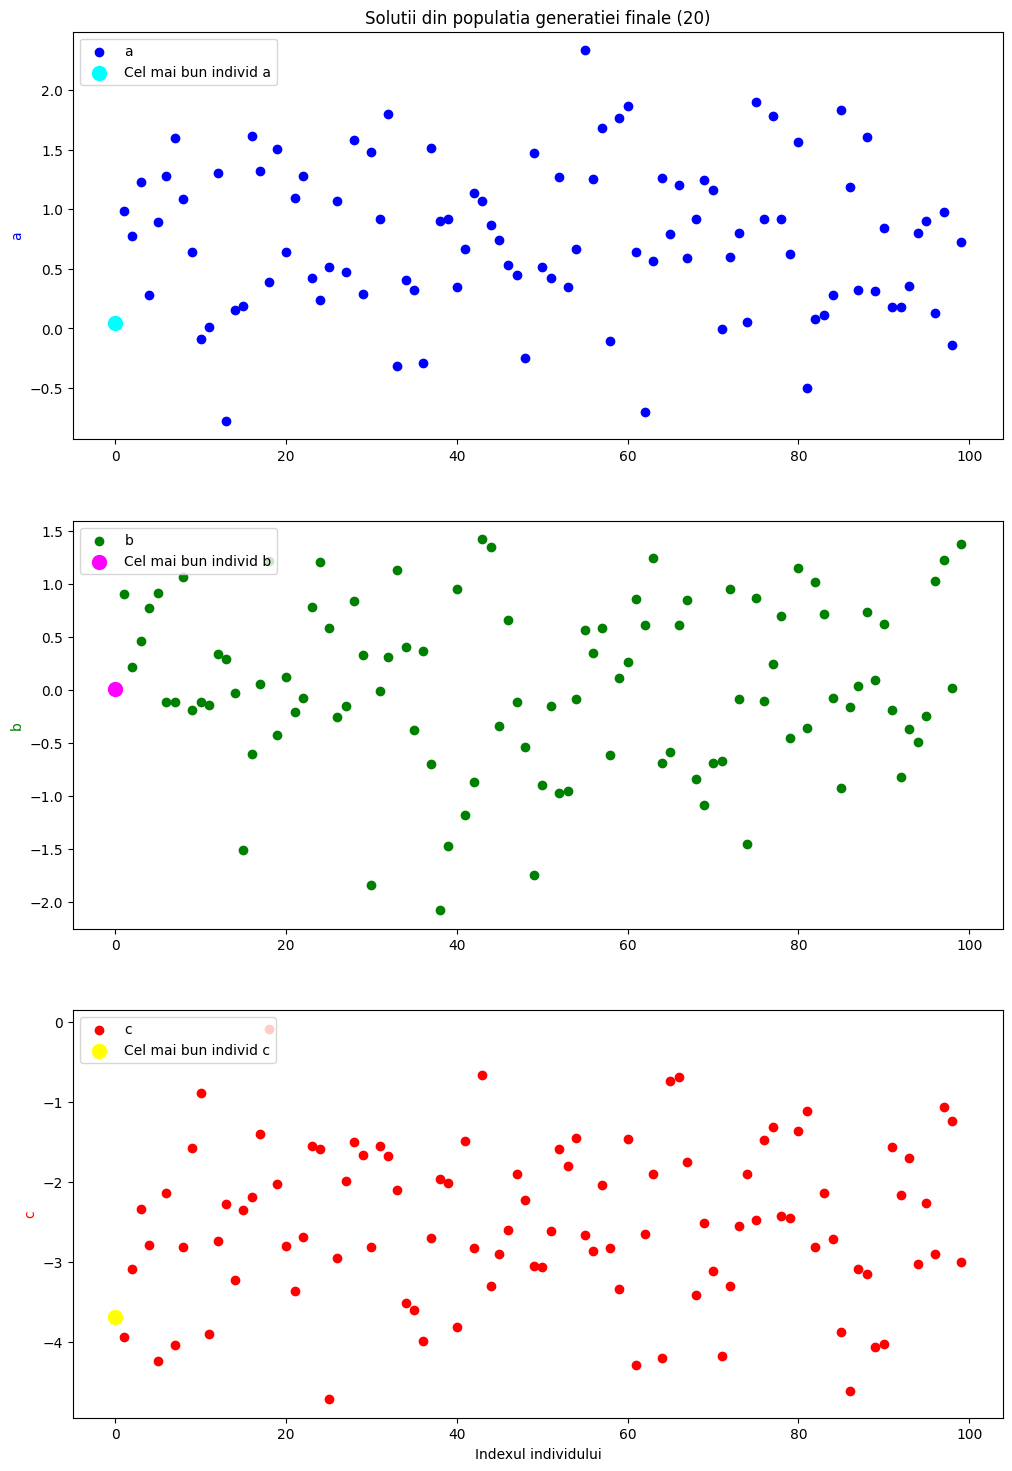

In [13]:
# Plot the final population
plot_final_population(result["all_populations"], result["best_performers"])


### Evoluția parametrilor

Acest grafic arată variația valorilor parametrilor (a, b, c) pentru cel mai bun individ, de la o generație la alta, ilustrând traiectoria de optimizare în spațiul parametrilor.


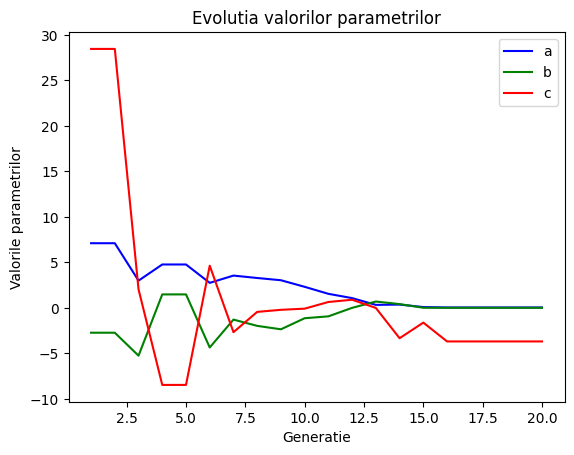

In [14]:
# Plot parameter evolution
plot_parameter_evolution(result["best_performers"])


### Evoluția fitness-ului

Acest grafic este un indicator cheie al performanței. Linia neagră arată evoluția scorului de fitness al celui mai bun individ, iar zona gri reprezintă intervalul de fitness (minim-maxim) din întreaga populație. O tendință ascendentă a liniei negre și îngustarea zonei gri indică un progres constant și convergența populației.


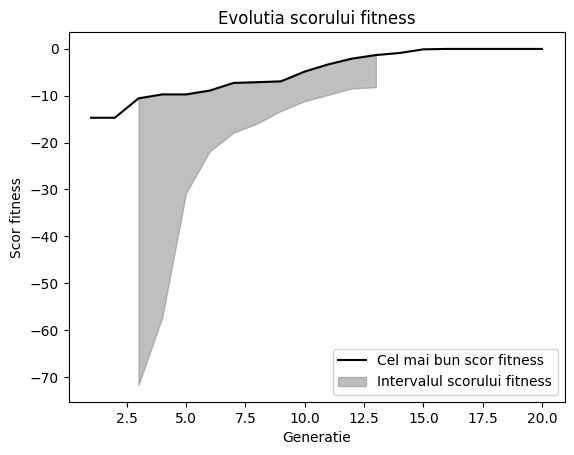

In [15]:
# Plot fitness evolution
plot_fitness_evolution(result["best_performers"], result["all_populations"])


### Evoluția funcțiilor pătratice

Acest grafic oferă o perspectivă directă asupra procesului de optimizare. Fiecare curbă reprezintă funcția pătratică a celui mai bun individ dintr-o generație. Se poate observa cum, de-a lungul generațiilor, algoritmul ajustează parametrii pentru a produce parabole progresiv mai plate, convergând astfel către soluția optimă.


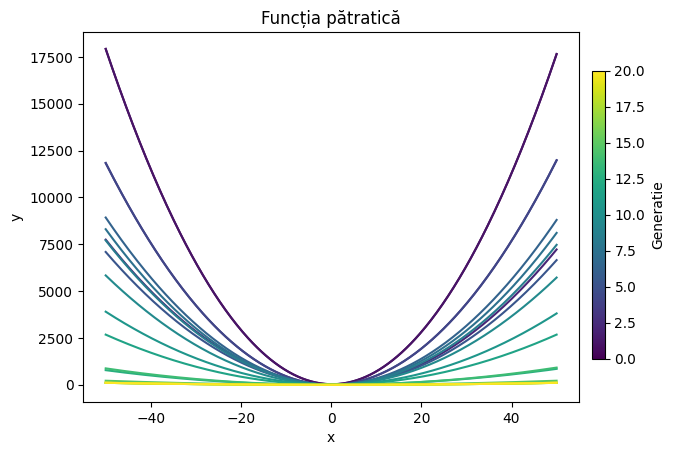

In [16]:
# Plot the quadratic functions across generations
plot_quadratic_functions(result["best_performers"], result["x_plot_min"], result["x_plot_max"], result["generations"])
plt.show()
